# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [42]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [43]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [45]:
total_0 = len(df[df['duration'] == 0])
total_lte5 = len(df[df['duration'] <= 5])

print(f"total rows with 0 second duration: {total_0}, total rows with duration <= 5s: {total_lte5}")

total rows with 0 second duration: 4, total rows with duration <= 5s: 53


In [46]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Initial Analysis
All 21 columns are present, and non have null rows.
There are multiple categorical columns which could be converted to numeric columns via category encoding. For example `job` and `marital` are categorical columns with < 10 values. `month` and `day_of_week` are ordinal data. There are also several boolean features which could be a good fit for one-hot econding.

There are also many columns which are already numeric (int64 or float64).

This should be a good data set for modelling given the number of numeric and numerically encodable features.

Worth noting: one observation shared in the UCI description of the data is that we should discard the `duration` field: 

```
last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
```

However from the original study they included `duration` and found it to be impactful in a different way than was flagged for UCI:

```
Call duration is the most relevant feature, meaning that
longer calls tend increase successes
```

In other words this information could be valuable in a real-world scenario (e.g. as a goal for the sales person performing the pitch to en sure they suprass a certain duration to improve their chances of a successful conversaion).

I also examined the dataset and there are only 4 / 41888 rows which have a duration of exactly 0 and 53 which have a duration <= 5 seconds. For these reasons I will include the `duration` feature.


### Exploratory Data Analysis

Before modeling, we examine key feature distributions and their relationship with the target variable (`y`) to surface patterns in the data.

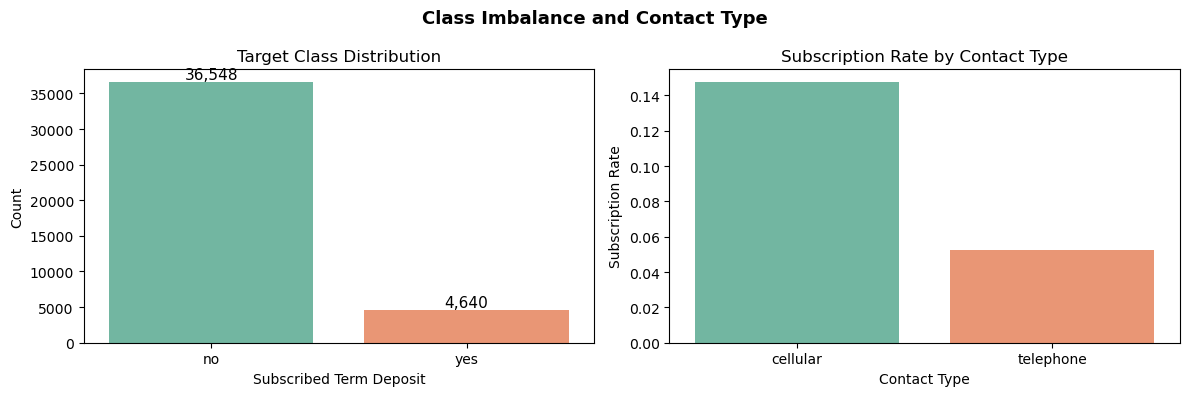

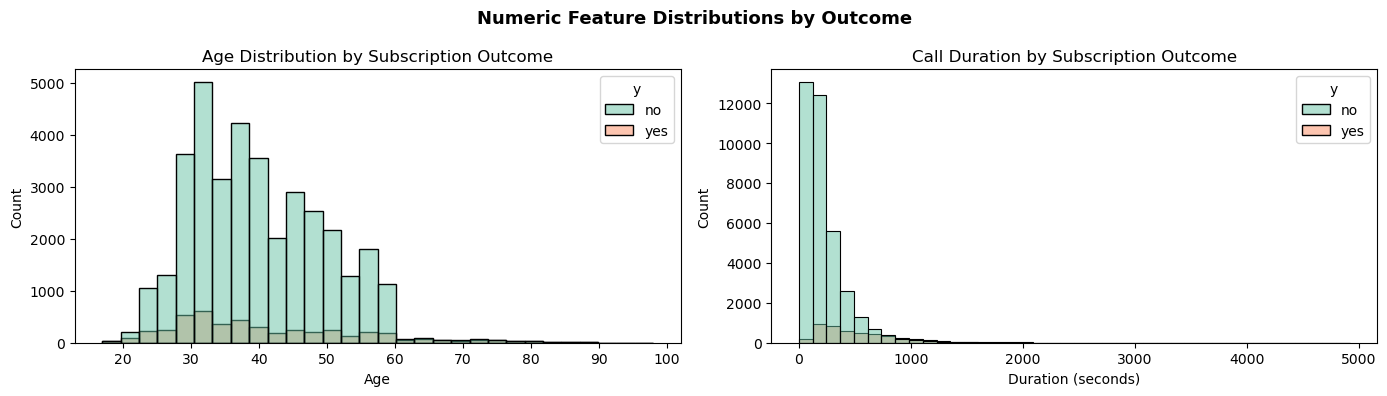

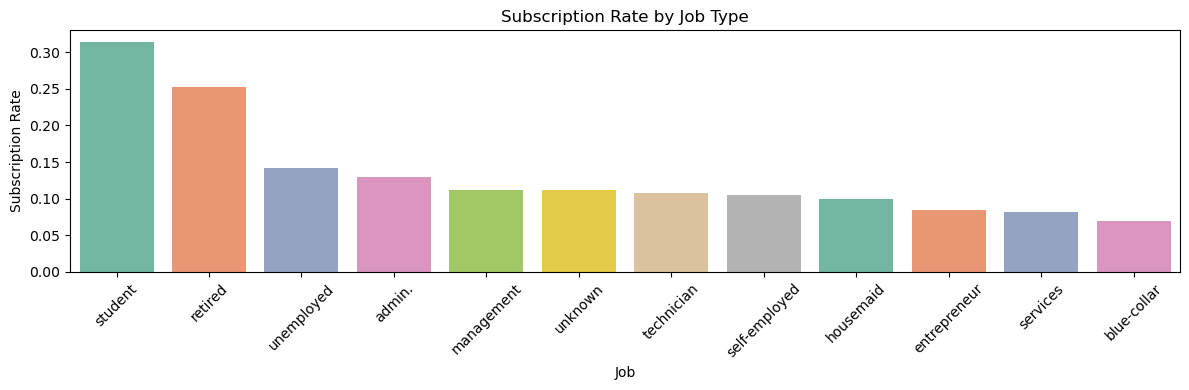

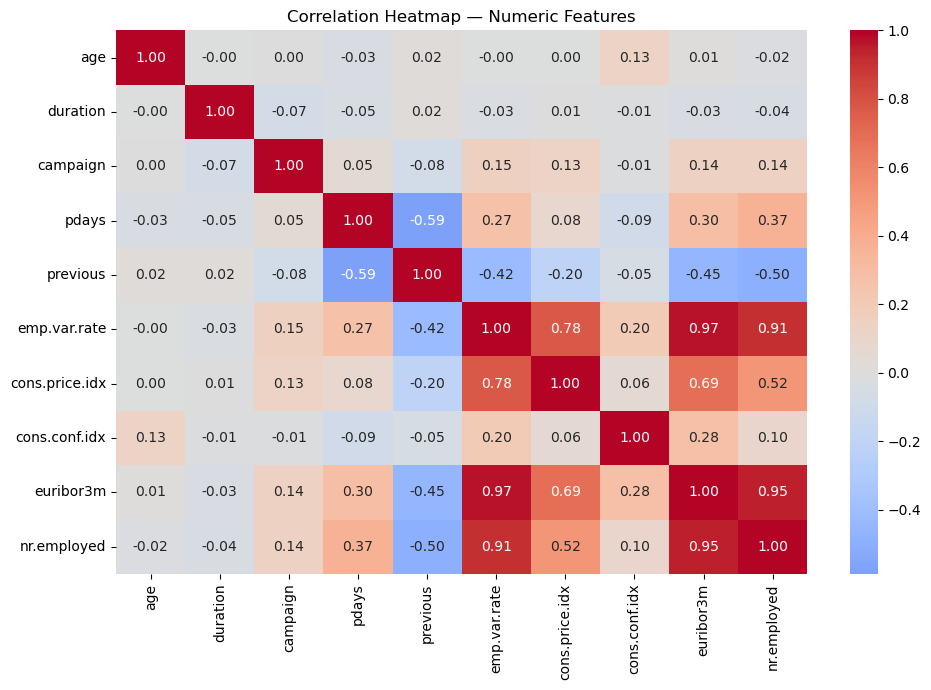

In [47]:
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('images', exist_ok=True)

# --- 1. Target class distribution and contact type subscription rate ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='y', data=df, order=['no', 'yes'], palette='Set2', ax=axes[0])
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('Subscribed Term Deposit')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

contact_rate = df.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean()).reset_index()
contact_rate.columns = ['contact', 'Subscription Rate']
sns.barplot(x='contact', y='Subscription Rate', data=contact_rate, palette='Set2', ax=axes[1])
axes[1].set_title('Subscription Rate by Contact Type')
axes[1].set_xlabel('Contact Type')
axes[1].set_ylabel('Subscription Rate')
plt.suptitle('Class Imbalance and Contact Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/class_distribution_contact_rate.png', bbox_inches='tight', dpi=150)
plt.show()

# --- 2. Age and call duration distributions by outcome ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x='age', hue='y', bins=30, palette='Set2', ax=axes[0])
axes[0].set_title('Age Distribution by Subscription Outcome')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.histplot(data=df, x='duration', hue='y', bins=40, palette='Set2', ax=axes[1])
axes[1].set_title('Call Duration by Subscription Outcome')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Count')
plt.suptitle('Numeric Feature Distributions by Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/age_duration_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# --- 3. Subscription rate by job type ---
fig, ax = plt.subplots(figsize=(12, 4))
job_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False).reset_index()
job_rate.columns = ['job', 'Subscription Rate']
sns.barplot(x='job', y='Subscription Rate', data=job_rate, palette='Set2', ax=ax)
ax.set_title('Subscription Rate by Job Type')
ax.set_xlabel('Job')
ax.set_ylabel('Subscription Rate')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/subscription_rate_by_job.png', bbox_inches='tight', dpi=150)
plt.show()

# --- 4. Correlation heatmap of numeric features ---
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Problem 4 Answer: Business Objective
Our business objective is to build a classification model to accurately predict whether a customer will subscribe to a product offering from a bank. For this task we will be using bank data captured from the UCI bank marketing dataset [here](https://archive.ics.uci.edu/dataset/222/bank+marketing). Our target variable name in the original dataset is `y` which is a boolean representing "has the client subscribed a term deposit?".

Our apprach will be to evaluate multiple classification models to determine which one is the best at predicting subscription outcomes from the marketing campaign. The specififc models we will eavaluate are Logistic Regression, KNN, Decision Tres, and Support Vector Machines (SVM).

---

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [48]:
df_encoded = df.copy()

# --- Target: encode y as binary ---
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# --- Ordinal features: preserve ordering ---
education_order = [['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree']]
month_order = [['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']]
day_order = [['mon', 'tue', 'wed', 'thu', 'fri']]

df_encoded['education'] = OrdinalEncoder(categories=education_order).fit_transform(df_encoded[['education']])
df_encoded['month'] = OrdinalEncoder(categories=month_order).fit_transform(df_encoded[['month']])
df_encoded['day_of_week'] = OrdinalEncoder(categories=day_order).fit_transform(df_encoded[['day_of_week']])

# --- Binary categorical features: yes/no/unknown → 1/0/-1 ---
for col in ['default', 'housing', 'loan']:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0, 'unknown': -1})

# contact has no unknown category
df_encoded['contact'] = df_encoded['contact'].map({'cellular': 1, 'telephone': 0})

# --- Nominal categorical features: one-hot encode ---
df_encoded = pd.get_dummies(df_encoded, columns=['job', 'marital', 'poutcome'], drop_first=False)

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

print(f"Feature matrix shape: {X.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")
X.head()

Feature matrix shape: (41188, 36)

Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64


,age,education,default,housing,loan,contact,month,day_of_week,duration,campaign,...,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,2.0,0,0,0,0,4.0,0.0,261,1,...,False,False,False,False,True,False,False,False,True,False
1,57,5.0,-1,0,0,0,4.0,0.0,149,1,...,False,False,False,False,True,False,False,False,True,False
2,37,5.0,0,1,0,0,4.0,0.0,226,1,...,False,False,False,False,True,False,False,False,True,False
3,40,3.0,0,0,0,0,4.0,0.0,151,1,...,False,False,False,False,True,False,False,False,True,False
4,56,5.0,0,0,1,0,4.0,0.0,307,1,...,False,False,False,False,True,False,False,False,True,False


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [49]:
# -- Classes are imbalanced -- stratify to ensure both splits maintain same ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")



Train target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [50]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

baseline_train_acc = dummy.score(X_train, y_train)
baseline_test_acc  = dummy.score(X_test, y_test)

print(f"Baseline (most frequent) train accuracy: {baseline_train_acc:.4f}")
print(f"Baseline (most frequent) test accuracy:  {baseline_test_acc:.4f}")

Baseline (most frequent) train accuracy: 0.8873
Baseline (most frequent) test accuracy:  0.8874


### Problem 7 Answer:
Our classifier must score above 88.74% on test accuracy in order to outperform the baseline.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [51]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000, random_state=42))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [56]:
lr_train_acc = lr_pipe.score(X_train, y_train)
lr_test_acc  = lr_pipe.score(X_test, y_test)

print(f"Logistic Regression train accuracy: {lr_train_acc:.4f}")
print(f"Logistic Regression test accuracy:  {lr_test_acc:.4f}")

Logistic Regression train accuracy: 0.9101
Logistic Regression test accuracy:  0.9122


### Problem 9 Answer:

The initial LR model has an accuracy of 91.22% on the test data (above the 88.74% baseline on test data).

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [57]:
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))])
knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])
dt_pipe = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))])
svm_pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=42))])

models = [
    ('Logistic Regression', lr_pipe),
    ('KNN', knn_pipe),
    ('Decision Tree', dt_pipe),
    ('SVM', svm_pipe),
]

results = []
for name, pipe in models:
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    results.append({
        'Model': name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(pipe.score(X_train, y_train), 4),
        'Test Accuracy': round(pipe.score(X_test, y_test), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.1140,0.9101,0.9122
KNN,0.0354,0.9238,0.9016
Decision Tree,0.1428,1.0000,0.8906
SVM,5.5998,0.9179,0.9122


### Problem 10 Answer:

The findings comparing different models are interesting. Logistic regression and SVM had the highest test accuracy scores at 91.22% each. However SVM took 5.4 seconds to run while Logistic Regression only took 0.12 seconds. KNN performed slightly better than baseline -- 90.16% accuracy -- but with a much faster runtime than Logistic Regression (0.03 seconds). The worst performing model was DecisionTree, with a test accuracy of only 89.06% (barely above the 88.74% baseline). Looking at the training results, most models had similar test and training accuracy scores, but DecisionTree had 100% accuracy on the training set, so it is overfitting. 

I think it will be interesting to see how performance changes as we adjust hyperparameters.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these. We expand our evaluation metrics beyond accuracy and tune hyperparameters for each model using `RandomizedSearchCV`.

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, roc_auc_score

scoring = {
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score),
}

tuned_models = {
    'Logistic Regression': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))]),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__max_iter': [1000],
            'model__solver': ['lbfgs', 'liblinear'],
        }
    },
    'KNN': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
        'params': {
            'model__n_neighbors': [5, 11, 21],
            'model__weights': ['uniform', 'distance'],
        }
    },
    'Decision Tree': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))]),
        'params': {
            'model__max_depth': [5, 10, 15],
            'model__min_samples_leaf': [5, 10],
            'model__criterion': ['gini', 'entropy'],
        }
    },
    'SVM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=42, probability=True))]),
        'params': {
            'model__C': [0.1, 1],
            'model__kernel': ['rbf', 'linear'],
        }
    },
}

best_estimators = {}
new_results = []
for name, config in tuned_models.items():
    print(f"Fitting {name}...")
    search = RandomizedSearchCV(
        config['pipeline'],
        config['params'],
        n_iter=10,
        scoring=scoring,
        refit='roc_auc',
        cv=5,
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    idx = search.best_index_
    best_estimators[name] = best

    new_results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'Precision': round(search.cv_results_['mean_test_precision'][idx], 4),
        'Recall': round(search.cv_results_['mean_test_recall'][idx], 4),
        'F1': round(search.cv_results_['mean_test_f1'][idx], 4),
        'ROC-AUC': round(search.cv_results_['mean_test_roc_auc'][idx], 4),
        'Test Accuracy': round(best.score(X_test, y_test), 4),
    })
    print(f"  Done. Best ROC-AUC: {search.best_score_:.4f}, params: {search.best_params_}\n")

new_results_df = pd.DataFrame(new_results).set_index('Model')
new_results_df

Fitting Logistic Regression...
  Done. Best ROC-AUC: 0.6886, params: {'model__solver': 'lbfgs', 'model__max_iter': 1000, 'model__C': 10}

Fitting KNN...
  Done. Best ROC-AUC: 0.6535, params: {'model__weights': 'distance', 'model__n_neighbors': 5}

Fitting Decision Tree...
  Done. Best ROC-AUC: 0.7386, params: {'model__min_samples_leaf': 10, 'model__max_depth': 5, 'model__criterion': 'entropy'}

Fitting SVM...
  Done. Best ROC-AUC: 0.6571, params: {'model__kernel': 'rbf', 'model__C': 1}



,Best Params,Precision,Recall,F1,ROC-AUC,Test Accuracy
Model,,,,,,
Logistic Regression,"{'model__solver': 'lbfgs', 'model__max_iter': ...",0.6629,0.4033,0.5014,0.6886,0.9121
KNN,"{'model__weights': 'distance', 'model__n_neigh...",0.5550,0.3419,0.4231,0.6535,0.9023
Decision Tree,"{'model__min_samples_leaf': 10, 'model__max_de...",0.6345,0.5148,0.5678,0.7386,0.9182
SVM,"{'model__kernel': 'rbf', 'model__C': 1}",0.6523,0.3370,0.4443,0.6571,0.9122


### Model Interpretation: Feature Coefficients and Importances

To understand *what* the models learned, we examine the Logistic Regression coefficients and Decision Tree feature importances. Positive LR coefficients increase the predicted probability of subscription; negative coefficients decrease it. Decision Tree importances measure how much each feature reduces impurity across all splits.

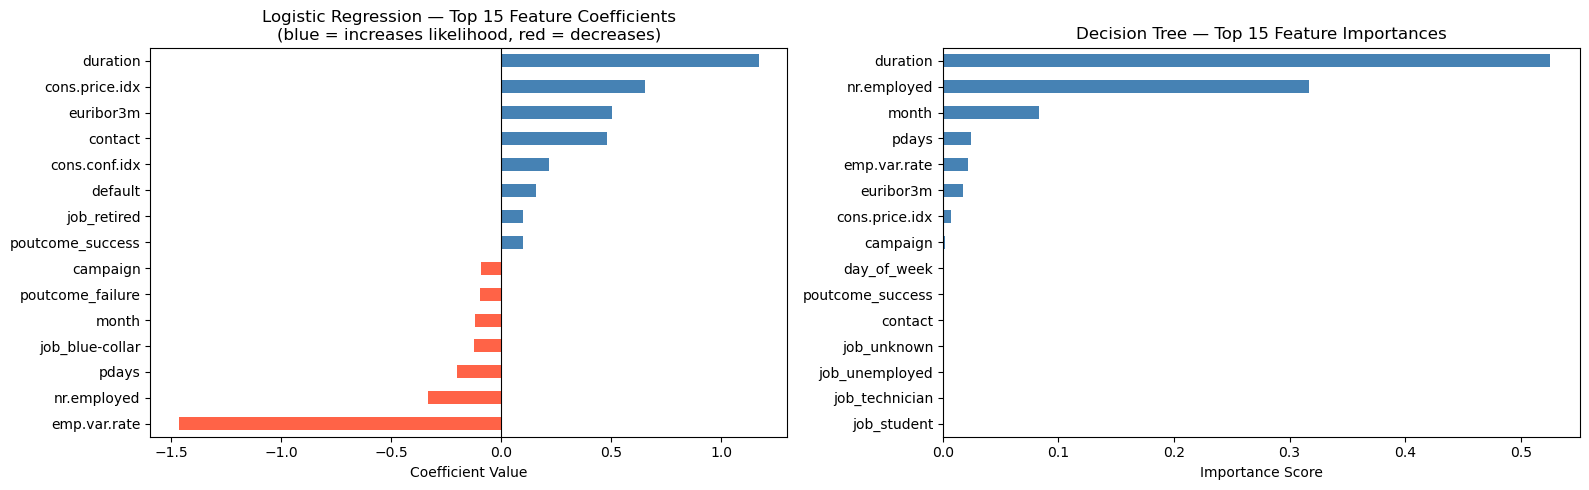

Top 5 LR features (positive coefficients — increase subscription likelihood):
duration          1.168831
cons.price.idx    0.653005
euribor3m         0.502096
contact           0.480046
cons.conf.idx     0.218654
dtype: float64

Top 5 Decision Tree features by importance:
duration        0.524929
nr.employed     0.316593
month           0.083217
pdays           0.023988
emp.var.rate    0.021637
dtype: float64


Exception ignored in: <function ResourceTracker.__del__ at 0x1070d9300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104d1d300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
Chi

In [59]:
# Logistic Regression — top feature coefficients
lr_best = best_estimators['Logistic Regression']
lr_coef = pd.Series(
    lr_best.named_steps['model'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_lr = ['steelblue' if v > 0 else 'tomato' for v in lr_coef.sort_values()]
lr_coef.sort_values().plot(kind='barh', ax=axes[0], color=colors_lr)
axes[0].set_title('Logistic Regression — Top 15 Feature Coefficients\n(blue = increases likelihood, red = decreases)')
axes[0].set_xlabel('Coefficient Value')
axes[0].axvline(0, color='black', linewidth=0.8)

# Decision Tree — top feature importances
dt_best = best_estimators['Decision Tree']
dt_imp = pd.Series(
    dt_best.named_steps['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

dt_imp.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Decision Tree — Top 15 Feature Importances')
axes[1].set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('images/feature_importance_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 5 LR features (positive coefficients — increase subscription likelihood):")
print(lr_coef.sort_values(ascending=False).head())
print("\nTop 5 Decision Tree features by importance:")
print(dt_imp.head())

### Problem 11 Findings

#### Expanding Beyond Accuracy

In the initial model comparison (Problem 10), we evaluated models solely on accuracy. However, given the significant class imbalance in this dataset (~89% "no", ~11% "yes"), accuracy alone is a misleading metric — a model that predicts "no" for every customer would score 88.7% without learning anything useful.

To get a more honest picture of model quality, we added four metrics to our evaluation:

- **Precision** — of all customers predicted to subscribe, what fraction actually did?
- **Recall** — of all actual subscribers, what fraction did the model catch?
- **F1** — harmonic mean of precision and recall; penalizes imbalance between the two
- **ROC-AUC** — measures ranking ability across all decision thresholds; robust to class imbalance

#### Hyperparameter Tuning

We used `RandomizedSearchCV` with `cv=5` and `refit='roc_auc'` to tune each model. ROC-AUC was chosen as the refit criterion because it evaluates model quality across all decision thresholds rather than committing to a fixed 0.5 cutoff, making it well-suited for imbalanced classification tasks.

We initially attempted full `GridSearchCV` but found it impractical on this dataset (~41,000 rows) — the SVM search alone ran for over 15 minutes without completing. `RandomizedSearchCV` with `n_iter=10` samples a random subset of hyperparameter combinations rather than exhaustively trying all of them, dramatically reducing runtime while still exploring the parameter space meaningfully.

#### Results Summary

| Model | Precision | Recall | F1 | ROC-AUC | Test Accuracy |
|-------|-----------|--------|----|---------|---------------|
| Logistic Regression | 0.6629 | 0.4033 | 0.5014 | 0.6886 | 0.9121 |
| KNN | 0.5550 | 0.3419 | 0.4231 | 0.6535 | 0.9023 |
| Decision Tree | **0.6345** | **0.5148** | **0.5678** | **0.7386** | **0.9182** |
| SVM | 0.6523 | 0.3370 | 0.4443 | 0.6571 | 0.9122 |

**Decision Tree** is the strongest performer across all meaningful metrics — best F1 (0.5678), best ROC-AUC (0.7386), best Recall (0.5148), and best Test Accuracy (0.9182). Hyperparameter tuning (`max_depth`, `min_samples_leaf`) also successfully resolved the overfitting observed in Problem 10, where the default Decision Tree achieved 100% train accuracy.

**Logistic Regression** is a competitive second — it achieves the highest precision (0.6629), meaning when it predicts a subscription it is most likely to be correct, but its recall (0.4033) is the weakest among all models except SVM.

**SVM and KNN** underperform relative to their computational cost. SVM in particular has the lowest recall (0.3370), meaning it misses roughly 2 out of 3 actual subscribers.

#### Interpretation

All models have modest F1 scores (0.42–0.57), which is expected given the class imbalance. The gap between accuracy (~90%) and F1 (~0.5) highlights that high accuracy is partially an artifact of the majority class. For this business problem — identifying bank customers likely to subscribe to a term deposit — **recall is arguably the most important metric**, since missing a potential subscriber represents lost revenue. On that basis, Decision Tree remains the recommended model.

### Next Steps and Recommendations

#### Recommended Model
Based on our evaluation, the **Decision Tree** with tuned hyperparameters is the recommended model. It achieved the best balance of recall (0.51), F1 (0.57), and ROC-AUC (0.74) across all four classifiers evaluated.

#### Actionable Insights for the Business

1. **Call duration is the strongest predictor** — Longer calls are strongly associated with successful subscriptions. Sales teams should be coached to keep prospects engaged past a minimum duration threshold, which could serve as a leading indicator of campaign success.

2. **Re-target prior subscribers** — Previous campaign outcome (`poutcome_success`) is a top predictor. Customers who subscribed in a prior campaign are significantly more likely to subscribe again and should be prioritized in outreach lists.

3. **Economic conditions influence outcomes** — Macroeconomic features (`euribor3m`, `emp.var.rate`) are highly correlated and predictive. Scheduling campaigns during favorable economic windows (lower rates, stable employment) may improve conversion.

4. **Prioritize cellular contact** — Cellular contact yields higher subscription rates than landline telephone. Where possible, prioritizing cellular outreach could meaningfully improve campaign efficiency.

#### Limitations and Next Steps

- **Class imbalance**: All models struggle with recall on the minority class (~11% positive rate). Adding `class_weight='balanced'` to model parameters or applying oversampling (e.g., SMOTE) are natural next steps that could meaningfully improve recall without requiring new data.

- **Decision threshold tuning**: Models currently predict "yes" when `predict_proba > 0.5`. Lowering this threshold increases recall at the cost of precision — the right tradeoff depends on the bank's campaign budget and cost per call.

- **Ensemble methods**: Random Forest or Gradient Boosting (XGBoost, LightGBM) typically outperform individual decision trees and would be strong candidates to evaluate in a follow-up study.

- **Feature selection**: With 36 engineered features, a dimensionality reduction step (e.g., using Decision Tree feature importances to drop low-signal features) could reduce noise and improve generalization.

##### Questions